In [1]:
import os
import json
import random
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import faiss
from tqdm import tqdm

from transformers import CLIPProcessor, CLIPModel

In [2]:
# -----------------------------
# Configuration
# -----------------------------
TRAIN_IMAGE_DIR = "dataset/flickr30k_images/train"
TRAIN_CAPTIONS_DIR = "dataset/captions-train.csv"

TEST_IMAGE_DIR = "dataset/flickr30k_images/test"
TEST_CAPTIONS_DIR = "dataset/captions-test.csv"

JSON_OUT = "image_metadata.json"

MODEL_NAME = "openai/clip-vit-base-patch32"
BATCH_SIZE = 16
NUM_WORKERS = 0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [3]:
# -----------------------------
# Dataset
# -----------------------------
class Flickr30KImageDataset(Dataset):
    """
    Dataset assumptions:
    - Images are named as integers with .jpg extension (e.g. 14121.jpg)
    - captions CSV has columns: image_name, caption_idx, caption
    - Multiple captions per image
    """

    def __init__(self, image_dir, captions_dir, processor: CLIPProcessor, transform=None):
        self.image_dir = image_dir
        self.processor = processor

        # Load captions CSV and group captions by image
        df = pd.read_csv(captions_dir)
        self.captions_per_image = df.groupby("image_name")["caption"].apply(list).to_dict()

        # Keep only images that actually exist on disk
        self.image_names = [
            img_name for img_name in self.captions_per_image.keys()
            if os.path.exists(os.path.join(self.image_dir, img_name))
        ]

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]          # e.g. "1000092795.jpg"
        image_path = os.path.join(self.image_dir, image_name)
        image = Image.open(image_path).convert("RGB")

        # Preprocess to tensor using CLIPProcessor
        # return_tensors='pt' → gives shape [1, 3, 224, 224], so squeeze to [3, 224, 224]
        processed = self.processor(images=image, return_tensors="pt")
        image_tensor = processed['pixel_values'].squeeze(0)  

        captions = self.captions_per_image[image_name]

        return {
            "image_tensor": image_tensor,   # CLIP-ready tensor
            "image_name": image_name,
            "captions": captions
        }
        
    

In [4]:
# -----------------------------
# CLIP model
# -----------------------------
model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
processor = CLIPProcessor.from_pretrained(MODEL_NAME, use_fast=True)

# Freeze CLIP parameters
model.eval()
for param in model.parameters():
    param.requires_grad = False

embedding_dim = model.visual_projection.out_features

In [5]:
# -----------------------------
# Collate function for stacking dictionaries while loading batches of data
# -----------------------------
def collate_fn(batch):
    collated = {}
    for key in batch[0]:
        values = [item[key] for item in batch]

        # If tensor, stack along new batch dimension
        if isinstance(values[0], torch.Tensor):
            collated[key] = torch.stack(values)
        else:
            # leave lists, strings, or other objects as-is
            collated[key] = values
    return collated


In [6]:
# -----------------------------
# Dataset & Loader
# -----------------------------
train_dataset = Flickr30KImageDataset(TRAIN_IMAGE_DIR, TRAIN_CAPTIONS_DIR, processor)
test_dataset  = Flickr30KImageDataset(TEST_IMAGE_DIR,  TEST_CAPTIONS_DIR, processor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

In [7]:
# -----------------------------
# FAISS index
# -----------------------------
faiss_index = faiss.IndexFlatIP(embedding_dim)  # cosine similarity (after normalization)

# -----------------------------
# Metadata storage
# -----------------------------
metadata = {}
current_index = 0

In [8]:
# -----------------------------
# Embedding + Indexing
# -----------------------------
loader = tqdm(train_loader, desc="Extracting CLIP embeddings")

for batch in loader:
    images = batch['image_tensor'].to(DEVICE) # shape [B, 3, 224, 224]
    image_names = batch['image_name']
    captions = batch['captions']
    
    with torch.no_grad():
        embeddings = model.get_image_features(images)
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
    
    embeddings_np = embeddings.cpu().numpy().astype(np.float32)
    faiss_index.add(embeddings_np)

    for i in range(len(images)):
        metadata[current_index] = {
            "title": image_names[i],
            "captions": captions[i]
        }
        current_index += 1

Extracting CLIP embeddings: 100%|██████████| 1924/1924 [03:56<00:00,  8.12it/s]


In [9]:
# -----------------------------
# Save FAISS index
# -----------------------------
faiss.write_index(faiss_index, "flickr30k_clip_images.faiss")


# -----------------------------
# Save metadata JSON
# -----------------------------
with open(JSON_OUT, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)


print(f"Indexed {faiss_index.ntotal} images")
print("FAISS index and metadata JSON saved.")


Indexed 30783 images
FAISS index and metadata JSON saved.


In [31]:
from PIL import Image

import matplotlib.pyplot as plt

def display_images(image_path1, image_path2):    
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    image1 = Image.open(image_path1)
    plt.imshow(image1)
    plt.axis('off')  # Turn off axis labels
    plt.title("Test Image")

    plt.subplot(1, 2, 2)
    image2 = Image.open(image_path2)
    plt.imshow(image2)
    plt.axis('off')  # Turn off axis labels
    plt.title("Test Image")

    plt.show()

In [32]:
# -----------------------------
# Retrievel Function
# -----------------------------
def retrieve_k_similar_images(query, k=1, processor=None):
    if processor is not None:
        query = processor(images=query, return_tensors="pt")
    query = query['image_tensor'].unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        embedding = model.get_image_features(query)
        embedding = embedding / embedding.norm(dim=-1, keepdim=True)
        
    embedding = embedding.cpu().numpy().astype(np.float32)
    distance, idx = faiss_index.search(embedding, k=k)
    
    print("Distances:", distance)
    print("Indices:", idx)
    
    return idx
    
    

Distances: [[0.8677685]]
Indices: [[26122]]


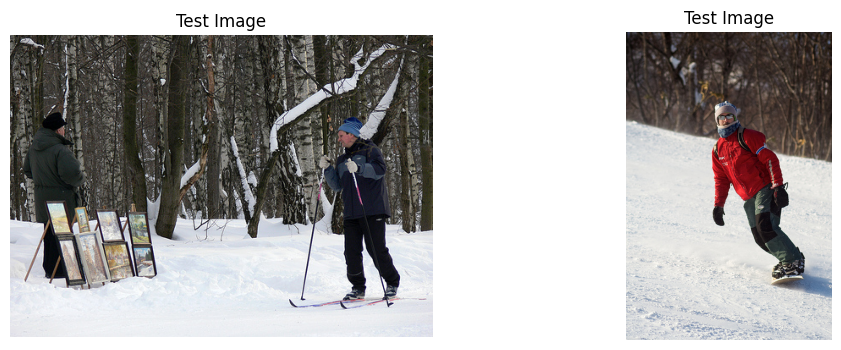

Distances: [[0.8557269]]
Indices: [[26975]]


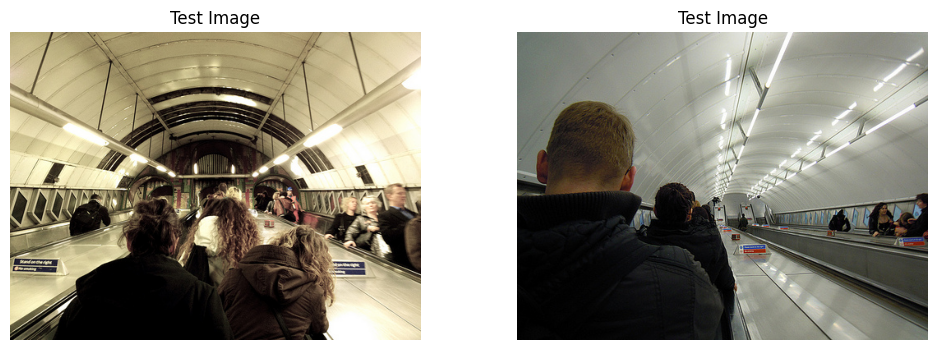

Distances: [[0.8687641]]
Indices: [[1934]]


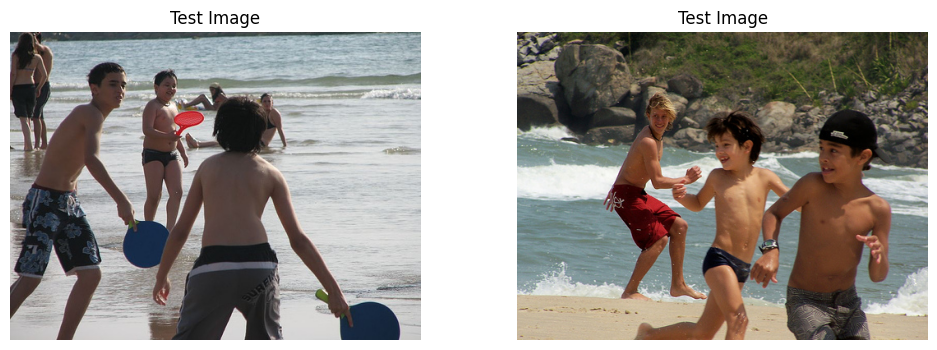

In [37]:
sample_idx = [1, 910, 25]
# retrieved_idx = retrieve_k_similar_images(test_dataset[sample_idx])

for i in range(len(sample_idx)):
    retrieved_idx = retrieve_k_similar_images(test_dataset[sample_idx[i]])
    
    base_path = "dataset/flickr30k_images"
    test_img_path = os.path.join(base_path, f'test/{test_dataset[sample_idx[i]]['image_name']}')
    retrieved_img_path = os.path.join(base_path, f'train/{train_dataset[retrieved_idx[0][0]]['image_name']}')
    display_images(test_img_path, retrieved_img_path)

In [27]:
test_dataset[910]['captions']

['A group of people is traveling through a terminal with moving walkways .',
 'Crowds of people are riding escalators up and down in a large tunnel .',
 'People at a terminal are on an elevator packed with others .',
 'A group of people stand on a moving sidewalk .',
 'A group of people going up an escalator .']

In [24]:
metadata[26975]

{'title': '5922190538.jpg',
 'captions': ['Several people going down an escalator  with a few others going up the up escalator .',
  'People are riding an escalator up and down a subway station tunnel .',
  'All the shoppers are moving up and down the escalator .',
  'People standing in line in a crowded area .',
  'People are lined up in a terminal']}

In [ ]:
import json

# Path to your saved JSON
json_path = "image_metadata.json"

with open(json_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

# Example: get info for FAISS index 0
print(metadata["0"])  # keys: 'title', 'captions', etc.


In [28]:
import faiss

faiss_index_path = "flickr30k_clip_images.faiss"

# Load FAISS index
faiss_index2 = faiss.read_index(faiss_index_path)

print(f"Number of vectors in index: {faiss_index2.ntotal}")


Number of vectors in index: 30783
